In [ ]:
# For train-test-val
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

FOLDERNAME = 'CollabCSV/assignment1 2/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/CollabCSV/assignment1 2/cs231n/datasets
/content/drive/My Drive/CollabCSV/assignment1 2


In [ ]:
# For train-test-val
import random
import numpy as np
import os
from cs231n.data_utils import load_CIFAR10
from PIL import Image
import matplotlib.pyplot as plt

# This is a bit of magic to make matplotlib figures appear inline in the notebook
# rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
#%load_ext autoreload
#%autoreload 2

In [ ]:
# Instead of this:
# X_objects = X_train_cifar[obj_indices].astype('uint8')

# Do this:
X_objects_raw = X_train_cifar[obj_indices]
# Weight the channels to get a standard luminance (0.299R + 0.587G + 0.114B)
X_objects_gray = 0.299 * X_objects_raw[:,:,:,0] + 0.587 * X_objects_raw[:,:,:,1] + 0.114 * X_objects_raw[:,:,:,2]
# Stack them back to 3 channels so your FCN code doesn't break
X_objects = np.stack([X_objects_gray] * 3, axis=-1).astype('uint8')

In [ ]:
# For train-test-val
# Load the raw CIFAR-10 data.
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Clear previously loaded data.
Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


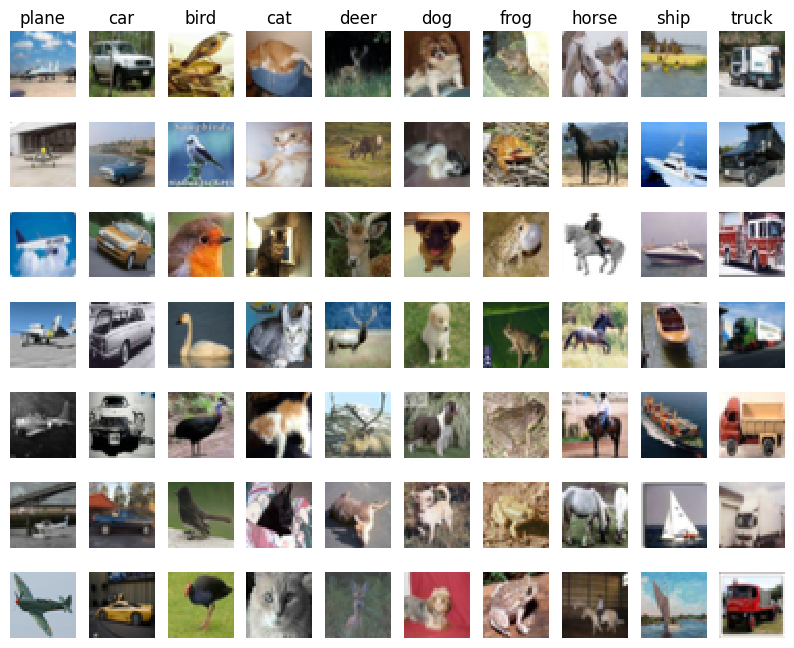

In [ ]:
# For train-test-val
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [ ]:
# LOAD HUMAN/MODEL COMP SET

# 1. Load the raw CIFAR-10 data
X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# 2. Extract the HUMAN dataset FIRST (while X_test is still 10,000 images)
num_human_comparison = 200
human_mask = list(range(500, 500 + num_human_comparison))
X_human = X_test[human_mask]
y_human = y_test[human_mask]

# 3. NOW subsample the data for the MODEL training/testing
num_training = 5000
train_mask = list(range(num_training))
X_train = X_train[train_mask]
y_train = y_train[train_mask]

num_test = 500
test_mask = list(range(num_test))
X_test = X_test[test_mask]   # Now X_test is reduced to 500
y_test = y_test[test_mask]

# 4. Reshape all of them into rows
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_human_flat = np.reshape(X_human, (X_human.shape[0], -1))

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"Human shape: {X_human_flat.shape}")



import os

# Define the path where you want to save (matching your previous folder)
save_path = '/content/drive/My Drive/CollabCSV/FILENAME'

# Option A: Save as a single compressed file (Best for keeping X and y together)
"""np.savez(os.path.join(save_path, 'human_comparison_data.npz'),
         X_human=X_human,
         y_human=y_human,
         X_human_flat=X_human_flat)"""

# Option B: Save as individual .npy files (Matching your mean_image style)
"""np.save(os.path.join(save_path, 'X_human_flat.npy'), X_human_flat)
np.save(os.path.join(save_path, 'y_human.npy'), y_human)"""

print(f"Datasets saved successfully to {save_path}")

Train shape: (5000, 3072)
Test shape:  (500, 3072)
Human shape: (200, 3072)


In [ ]:
import os
from PIL import Image
import numpy as np # Ensure numpy is imported

def load_and_format_faces(root_dir, target_size=(32, 32), max_samples=200):
    faces = []
    count = 0

    # Iterate through subjects
    for i in range(1, 41):
        if count >= max_samples:
            break

        subject_path = os.path.join(root_dir, f's{i}')
        if os.path.exists(subject_path):
            for filename in os.listdir(subject_path):
                if count >= max_samples:
                    break
                if filename.lower().endswith(('.pgm', '.jpg', '.jpeg')):
                    img_path = os.path.join(subject_path, filename)

                    # Process image
                    img = Image.open(img_path).convert('L')
                    img = img.resize(target_size)

                    # Convert to RGB (3 channels) to match CIFAR
                    img_rgb = np.stack([np.array(img)] * 3, axis=-1)
                    faces.append(img_rgb)
                    count += 1

    return np.array(faces, dtype='uint8') # Use uint8 to save RAM


# --- STEP 1: LOAD RAW SOURCES ---
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'
X_train_cifar, y_train_cifar, X_test_cifar, y_test_cifar = load_CIFAR10(cifar10_dir)
face_path = '/content/drive/My Drive/CollabCSV/archive'

# --- STEP 2: PROCESS OBJECTS (GRAYSCALE FIX) ---
# We take 200 for project data and 100 for human test data
obj_indices = np.random.choice(X_train_cifar.shape[0], 300, replace=False)
X_objs_raw = X_train_cifar[obj_indices]

# Convert Objects to Grayscale to match Faces
X_objs_gray = 0.299*X_objs_raw[...,0] + 0.587*X_objs_raw[...,1] + 0.114*X_objs_raw[...,2]
X_objs_3ch = np.stack([X_objs_gray]*3, axis=-1).astype('uint8')

# Split objects into Project vs Human
X_objects_project = X_objs_3ch[:200]
X_objects_human = X_objs_3ch[200:]

# --- STEP 3: PROCESS FACES ---
# Load 200 for project and 100 for human (Total 300)
X_faces_all = load_and_format_faces(face_path, max_samples=300)
X_faces_project = X_faces_all[:200]
X_faces_human = X_faces_all[200:]

# --- STEP 4: CREATE MAIN PROJECT DATA (ffa_project_data.npz) ---
X_combined = np.concatenate([X_faces_project, X_objects_project], axis=0)
y_combined = np.concatenate([np.ones(200), np.zeros(200)]) # 1=Face, 0=Object

# Shuffle
indices = np.random.permutation(len(X_combined))
X_combined, y_combined = X_combined[indices], y_combined[indices]

# Create Splits (300 Train, 50 Val, 50 Test)
X_train, y_train = X_combined[:300], y_combined[:300]
X_val, y_val     = X_combined[300:350], y_combined[300:350]
X_test, y_test   = X_combined[350:], y_combined[350:]

np.savez_compressed('/content/drive/My Drive/CollabCSV/assignment1 2/ffa_project_data.npz',
                    X_train=X_train, y_train=y_train,
                    X_val=X_val, y_val=y_val,
                    X_test=X_test, y_test=y_test)

# --- STEP 5: CREATE HUMAN DATA (human_comparison_data.npz) ---
X_human = np.concatenate([X_faces_human, X_objects_human], axis=0)
y_human = np.concatenate([np.ones(100), np.zeros(100)])
X_human_flat = X_human.reshape(X_human.shape[0], -1).astype(np.float64)

np.savez('/content/drive/My Drive/CollabCSV/assignment1 2/human_comparison_data.npz',
         X_human=X_human, y_human=y_human, X_human_flat=X_human_flat)

print("Data pipeline complete. Project and Human sets are unique and color-neutral.")

✅ Data pipeline complete. Project and Human sets are unique and color-neutral.


In [ ]:
import numpy as np

# 1. Load both saved files
project_data = np.load('/content/drive/My Drive/CollabCSV/FILENAME/ffa_project_data.npz')
human_data = np.load('/content/drive/My Drive/CollabCSV/FILENAME/human_comparison_data.npz')

# 2. Combine all "seen" data (Train + Val + Test) into one master set
# We flatten them to make sure the comparison is straightforward
seen_images = np.vstack([
    project_data['X_train'].reshape(project_data['X_train'].shape[0], -1),
    project_data['X_val'].reshape(project_data['X_val'].shape[0], -1),
    project_data['X_test'].reshape(project_data['X_test'].shape[0], -1)
])

# 3. Get the human images
human_images = human_data['X_human_flat']

# 4. Convert to a set of bytes for high-speed searching
# Sets in Python use hashing, making this check nearly instant
seen_set = {row.tobytes() for row in seen_images}

duplicates = 0
for i, row in enumerate(human_images):
    if row.tobytes() in seen_set:
        duplicates += 1
        print(f"Warning: Human Image at index {i} is a duplicate of a training/val image!")

# 5. Final Report
if duplicates == 0:
    print("-" * 30)
    print("AUDIT PASSED: 0 Overlap Detected.")
    print(f"Total unique images in Project Set: {len(seen_images)}")
    print(f"Total unique images in Human Set:   {len(human_images)}")
    print("-" * 30)
else:
    print("-" * 30)
    print(f"AUDIT FAILED: {duplicates} overlapping images found.")
    print("You should re-run the dataset creation script to get fresh random indices.")
    print("-" * 30)

------------------------------
✅ AUDIT PASSED: 0 Overlap Detected.
Total unique images in Project Set: 400
Total unique images in Human Set:   200
------------------------------


In [ ]:
# COMPARE train-test-val sets + human/model comp set
import numpy as np

# 1. Load both datasets
data_main = np.load('/content/drive/My Drive/CollabCSV/FILENAME/ffa_project_data.npz')
data_human = np.load('/content/drive/My Drive/CollabCSV/FILENAME/human_comparison_data.npz')

# 2. Extract the flattened versions (easiest to compare)
# We combine Train, Val, and Test into one big "Already Seen" pool
seen_data = np.vstack([
    data_main['X_train'],
    data_main['X_val'],
    data_main['X_test']
])

human_data = data_human['X_human_flat']

# 3. Perform the Check
# We convert each row to a "bytes" object and store in a set for O(1) lookup speed
seen_set = {row.tobytes() for row in seen_data}
overlap_count = 0

for i, row in enumerate(human_data):
    if row.tobytes() in seen_set:
        overlap_count += 1
        print(f"Warning: Human Image index {i} found in the main dataset!")

if overlap_count == 0:
    print("Success: Zero overlap detected!")
else:
    print(f"Failure: {overlap_count} overlapping images found.")

In [ ]:
# To load the .npz file:
human_data = np.load('/content/drive/My Drive/CollabCSV/FILENAME/human_comparison_data.npz')

X_human = human_data['X_human']           # The raw images for YOU to look at
X_human_flat = human_data['X_human_flat'] # The flattened data for the MODEL
y_human = human_data['y_human']           # The ground truth labels

# Load the mean image you saved earlier
mean_image = np.load('mean_image.npy')
# Normalize the human data before giving it to the model
X_human_normalized = X_human_flat.astype(np.float32) - mean_image
# NOW you can use it:
# model_predictions = best_softmax.predict(X_human_normalized)


# 1. Prepare data for the MODEL
mean_image = np.load('mean_image.npy')
X_human_normalized = X_human_flat.astype(np.float32) - mean_image

# 2. Prepare data for the HUMAN
# We use the raw X_human (N, 32, 32, 3)
def show_human_image(index):
    img = X_human[index]

    # Ensure the data type is uint8 (0-255) for clear display
    plt.imshow(img.astype('uint8'))
    plt.axis('off')
    plt.title(f"Human View - Image #{index}")
    plt.show()

# Example: Show the first image to a human
show_human_image(0)

# Example: Get the model's prediction for that same image
# model_pred = best_softmax.predict(X_human_normalized[0:1])

In [ ]:
from cs231n.classifiers import KNearestNeighbor

# Create a kNN classifier instance.
# Remember that training a kNN classifier is a noop:
# the Classifier simply remembers the data and does no further processing
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

In [ ]:
print("X_test shape:", X_test.shape)
print("X_train shape:", classifier.X_train.shape)

print("First test example:", X_test[0][:10])
print("First train example:", classifier.X_train[0][:10])

print("Are first test/train equal?", np.all(X_test[0] == classifier.X_train[0]))

print("Sum of X_test:", np.sum(X_test))
print("Sum of X_train:", np.sum(classifier.X_train))

X_test shape: (500, 3072)
X_train shape: (5000, 3072)
First test example: [158. 112.  49. 159. 111.  47. 165. 116.  51. 166.]
First train example: [59. 62. 63. 43. 46. 45. 50. 48. 43. 68.]
Are first test/train equal? False
Sum of X_test: 189685566.0
Sum of X_train: 1850223105.0


In [ ]:
import os
import numpy as np
from PIL import Image

# 1. Lowered the sample counts to reduce memory footprint
num_faces_to_load = 200
num_objects_to_load = 200

def load_and_format_faces(root_dir, target_size=(32, 32), max_samples=200):
    faces = []
    count = 0

    # Iterate through subjects
    for i in range(1, 41):
        if count >= max_samples:
            break

        subject_path = os.path.join(root_dir, f's{i}')
        if os.path.exists(subject_path):
            for filename in os.listdir(subject_path):
                if count >= max_samples:
                    break
                if filename.lower().endswith(('.pgm', '.jpg', '.jpeg')):
                    img_path = os.path.join(subject_path, filename)

                    # Process image
                    img = Image.open(img_path).convert('L')
                    img = img.resize(target_size)

                    # Convert to RGB (3 channels) to match CIFAR
                    img_rgb = np.stack([np.array(img)] * 3, axis=-1)
                    faces.append(img_rgb)
                    count += 1

    return np.array(faces, dtype='uint8') # Use uint8 to save RAM

# --- Process Objects ---
obj_indices = np.random.choice(X_train_cifar.shape[0], num_objects_to_load, replace=False)
X_objects = X_train_cifar[obj_indices].astype('uint8')
y_objects = np.zeros(num_objects_to_load)

# --- Process Faces ---
# Ensure the path points exactly to where the 's1', 's2' folders are
face_path = '/content/drive/My Drive/CollabCSV/archive'
X_faces = load_and_format_faces(face_path, max_samples=num_faces_to_load)
y_faces = np.ones(len(X_faces))

# --- Combine and Shuffle ---
X_combined = np.concatenate([X_faces, X_objects], axis=0)
y_combined = np.concatenate([y_faces, y_objects], axis=0)

indices = np.random.permutation(len(X_combined))
X_combined = X_combined[indices]
y_combined = y_combined[indices]

# --- New Smaller Splits (Total 400) ---
# Train: 300, Val: 50, Test: 50
X_train, y_train = X_combined[:300], y_combined[:300]
X_val, y_val = X_combined[300:350], y_combined[300:350]
X_test, y_test = X_combined[350:], y_combined[350:]

# --- Save ---
save_path = '/content/drive/My Drive/CollabCSV/FILENAME/ffa_project_data.npz'
np.savez_compressed(save_path,
                    X_train=X_train, y_train=y_train,
                    X_val=X_val, y_val=y_val,
                    X_test=X_test, y_test=y_test)

print(f"Success! Saved {len(X_combined)} total images to: {save_path}")

Success! Saved 400 total images to: /content/drive/My Drive/CollabCSV/assignment1 2/ffa_project_data.npz


In [ ]:
# Load your saved dataset
data = np.load('/content/drive/My Drive/CollabCSV/FILENAME/ffa_project_data.npz')

X_train = data['X_train']
y_train = data['y_train']
X_val   = data['X_val']
y_val   = data['y_val']
X_test  = data['X_test']
y_test  = data['y_test']

print('Train:', X_train.shape, y_train.shape)
print('Val:  ', X_val.shape,   y_val.shape)
print('Test: ', X_test.shape,  y_test.shape)

# Flatten images: (N, 32, 32, 3) -> (N, 3072)
X_train_flat = X_train.reshape(X_train.shape[0], -1).astype(np.float64)
X_val_flat   = X_val.reshape(X_val.shape[0], -1).astype(np.float64)
X_test_flat  = X_test.reshape(X_test.shape[0], -1).astype(np.float64)

# Normalize by subtracting mean pixel (computed on train set only)
mean_pixel = X_train_flat.mean(axis=0)
X_train_flat -= mean_pixel
X_val_flat   -= mean_pixel
X_test_flat  -= mean_pixel

print('Flattened shapes:')
print('Train:', X_train_flat.shape)
print('Val:  ', X_val_flat.shape)
print('Test: ', X_test_flat.shape)

Train: (300, 32, 32, 3) (300,)
Val:   (50, 32, 32, 3) (50,)
Test:  (50, 32, 32, 3) (50,)
Flattened shapes:
Train: (300, 3072)
Val:   (50, 3072)
Test:  (50, 3072)


In [ ]:
# kNN Block

# Setup steps
import random
import numpy as np
import matplotlib.pyplot as plt

# This is a bit of magic to make matplotlib figures appear inline in the notebook
# rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
# %load_ext autoreload
# %autoreload 2

from cs231n.classifiers import KNearestNeighbor

# Create a kNN classifier instance.
# Remember that training a kNN classifier is a noop:
# the Classifier simply remembers the data and does no further processing
classifier = KNearestNeighbor()

# Use the flattened and normalized data from cell o6MOewDEqTap
# The current X_train and X_test are 4D arrays (num_samples, 32, 32, 3)
# They need to be reshaped to 2D arrays (num_samples, 3072)
# The flattened and normalized versions are already available as X_train_flat and X_test_flat

classifier.train(X_train_flat, y_train)

# Compute distances using the appropriate method from the classifier
# We assume `compute_distances_no_loops` is implemented in the KNearestNeighbor class
dists = classifier.compute_distances_no_loops(X_test_flat)

# Now implement the function predict_labels and run the code below:
# We use k = 1 (which is Nearest Neighbor).
y_test_pred = classifier.predict_labels(dists, k=50)

# Compute and print the fraction of correctly predicted examples
num_test_samples = X_test_flat.shape[0] # Use the correct number of test samples for the current dataset
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test_samples
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test_samples, accuracy))
print("First 10 predicted labels:", y_test_pred[:10])
print("First 10 actual labels:   ", y_test[:10])

k_values = [1, 5, 10, 20, 50]
for k in k_values:
    y_pred = classifier.predict_labels(dists, k=k)
    acc = np.mean(y_pred == y_test)
    print(f'k={k:3d} => accuracy: {acc:.4f}')

Got 22 / 50 correct => accuracy: 0.440000
First 10 predicted labels: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
First 10 actual labels:    [1. 1. 1. 1. 0. 0. 1. 0. 0. 1.]
k=  1 => accuracy: 0.4400
k=  5 => accuracy: 0.4400
k= 10 => accuracy: 0.4400
k= 20 => accuracy: 0.4400
k= 50 => accuracy: 0.4400


Faces - Min: 9, Max: 227, Mean: 118.12
Objects - Min: 0, Max: 255, Mean: 119.20


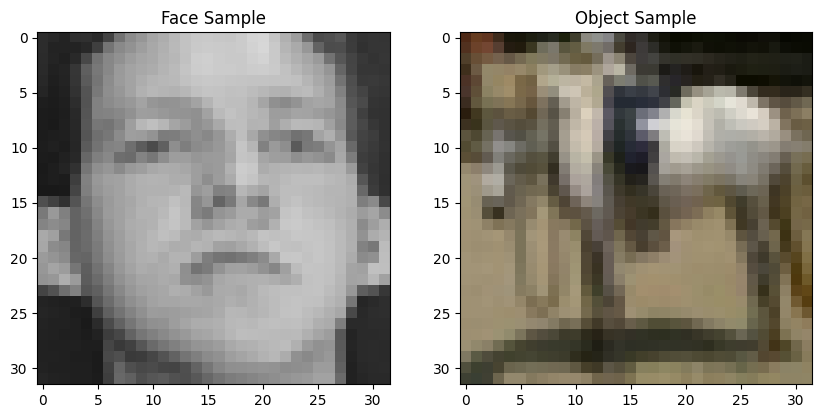

In [ ]:
print(f"Faces - Min: {X_faces.min()}, Max: {X_faces.max()}, Mean: {X_faces.mean():.2f}")
print(f"Objects - Min: {X_objects.min()}, Max: {X_objects.max()}, Mean: {X_objects.mean():.2f}")

fig, ax = plt.subplots(1, 2)
ax[0].imshow(X_faces[0].reshape(32, 32, 3).astype('uint8'))
ax[0].set_title("Face Sample")
ax[1].imshow(X_objects[0].reshape(32, 32, 3).astype('uint8'))
ax[1].set_title("Object Sample")
plt.show()